# Mục lục (Table of Contents)

- [1. Tensor](#sec1)
  - [1.1. Các loại tensor](#sec1_1)
  - [1.2. Thông tin của tensor](#sec1_2)
  - [1.3. Các phép toán](#sec1_3)
  - [1.4. Reshape và view](#sec1_4)
  - [1.5. Một số lưu ý](#sec1_5)
- [2. Sử dụng autograd để tính gradient](#sec2)
  - [2.1. Autograd là gì?](#sec2_1)
- [3. Xây dựng mạng neuron với nn.Sequential](#sec3)
  - [3.1. Fully-connected layer: nn.Linear](#sec3_1)
  - [3.2. Note](#sec3_2)
- [4. Custom module với nn.Module](#sec4)
  - [4.1. Cấu tạo](#sec4_1)
  - [4.2. So sánh với sequential only](#sec4_2)
- [5. Training loop](#sec5)
  - [5.1. Các bước của training loop](#sec5_1)
  - [5.2. Hàm mất mát và optimizer](#sec5_2)
  - [5.3. Train bài toán XOR](#sec5_3)
- [6. Dataset và DataLoader](#sec6)
- [7. Xây dựng MLP cho phân loại MNIST](#sec7)
  - [7.1. Multi-Layer Perceptron (MLP)](#sec7_1)
- [8. Thêm dropout và weight decay để giảm overfitting](#sec8)
  - [8.1. Dropout](#sec8_1)
  - [8.2. Weight decay](#sec8_2)
  - [8.3. Train và đánh giá mô hình](#sec8_3)
- [9. Sử dụng TensorBoard để theo dõi loss](#sec9)
  - [9.1. Chạy tensor board](#sec9_1)
- [10. Lưu và load model checkpoint](#sec10)
  - [10.1. State dict](#sec10_1)
- [11. Tinh chỉnh learning rate schedule](#sec11)

In [1]:
import torch

<a id="sec1"></a>
# __1. Tensor__

<a id="sec1_1"></a>
## 1.1. Các loại tensor
|Số chiều|Tên gọi|Ví dụ|
|-|-|-|
|0-D|scalar (vô hướng)| `torch.tensor(7)`|
|1-D|vector|`torch.tensor([1,2,3])`|
|2-D|ma trận|`torch.tensor([[1,2], [3,4]])`|
|3-D+|khối (ảnh, batch)|ảnh RGB (3, 16, 16)|

In [2]:
print(torch.tensor([[1, 2, 3], [4, 5, 6]]) )

tensor([[1, 2, 3],
        [4, 5, 6]])


Các hàm nhanh

In [3]:
# tạo ma trận n x m toàn số 0
print("zero matrix\n", torch.zeros(2, 3))

# tạo ma trận n x m toàn số 1
print("1 matrix\n", torch.ones(2,3))

# tạo ma trận ngẫu nhiên trong khoảng [0,1)
print('random matrix\n', torch.rand(2,3))

zero matrix
 tensor([[0., 0., 0.],
        [0., 0., 0.]])
1 matrix
 tensor([[1., 1., 1.],
        [1., 1., 1.]])
random matrix
 tensor([[0.8365, 0.5443, 0.4049],
        [0.1570, 0.7307, 0.2467]])


<a id="sec1_2"></a>
## 1.2. Thông tin của tensor

In [4]:
x = torch.rand(3, 4)
print(f"shape: {x.shape}") # torch.Size([3, 4]) -> 3 hàng 4 cột
print(f"Kiểu dữ liệu: {x.dtype}")
print(f"device: {x.device}")

shape: torch.Size([3, 4])
Kiểu dữ liệu: torch.float32
device: cpu


<a id="sec1_3"></a>
## 1.3. Các phép toán

In [5]:
a = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
b = torch.tensor([[10.0, 20.0], [30.0, 40.0]])

In [6]:
# cộng ma trận
print(a + b)

tensor([[11., 22.],
        [33., 44.]])


In [7]:
# Nhân từng phần tử
print(a * b)

tensor([[ 10.,  40.],
        [ 90., 160.]])


In [8]:
# Nhân 2 ma trận
print(a @ b)
print(a.matmul(b))

tensor([[ 70., 100.],
        [150., 220.]])
tensor([[ 70., 100.],
        [150., 220.]])


<a id="sec1_4"></a>
## 1.4. `reshape` và `view`

In [9]:
x = torch.rand(2, 3)
print(x)

tensor([[0.8852, 0.7419, 0.8664],
        [0.0632, 0.3564, 0.6496]])


In [10]:
# 2 cái như nhau
print(x.reshape(3, 2))
print(x.view(3, 2))

tensor([[0.8852, 0.7419],
        [0.8664, 0.0632],
        [0.3564, 0.6496]])
tensor([[0.8852, 0.7419],
        [0.8664, 0.0632],
        [0.3564, 0.6496]])


In [11]:
# Ứng dụng khi trải phẳng cho fully connected layer
print(x.reshape(6))
print(x.view(6))
print(x.view(6).shape)

# Nhưng nhược điểm là phải biết trước có bao nhiêu phần tử nên thay vào đó chúng ta dùng flatten()
print(x.flatten())
print(x.flatten().shape)

tensor([0.8852, 0.7419, 0.8664, 0.0632, 0.3564, 0.6496])
tensor([0.8852, 0.7419, 0.8664, 0.0632, 0.3564, 0.6496])
torch.Size([6])
tensor([0.8852, 0.7419, 0.8664, 0.0632, 0.3564, 0.6496])
torch.Size([6])


<a id="sec1_5"></a>
## 1.5. Một số lưu ý
+ Deep learning cần `float32` để tính đạo hàm
+ Tensor là `numpy array` nhưng thêm khả năng chạy trên `GPU` và `autograd`

<a id="sec2"></a>
# __2. Sử dụng autograd để tính gradient__

<a id="sec2_1"></a>
## 2.1. Autograd là gì?
autograd là “kế toán tự động” của PyTorch: mỗi khi bạn thực hiện phép tính trên tensor có bật theo dõi, nó âm thầm ghi lại “ai sinh ra ai”. Khi bạn gọi `.backward()`, nó chạy ngược lại chuỗi ghi chép đó, áp chain rule ở từng bước, và điền gradient vào chỗ cần.

In [12]:
# Quy trình chuẩn gồm ba nhịp: tính xuôi ra một số vô hướng (scalar) -> gọi .backward() -> đọc .grad.
x = torch.tensor(3.0, requires_grad=True)
y = x ** 2
y.backward() # tính dy/dx
print(x.grad)

tensor(6.)


<a id="sec3"></a>
# __3. Xây dựng mạng neuron với nn.Sequential__

In [13]:
from torch import nn

<a id="sec3_1"></a>
## 3.1. Fully-connected layer: `nn.Linear`
Khi gọi `nn.Linear(in_features, out_features)` thì trong nó đã tự tạo 1 `weight` và `bias`

In [14]:
fc = nn.Linear(3, 2)

In [15]:
print(fc.weight, "\n\n\n", fc.bias)

Parameter containing:
tensor([[-0.5498, -0.0631, -0.4537],
        [ 0.0113,  0.5553, -0.4225]], requires_grad=True) 


 Parameter containing:
tensor([0.1138, 0.4437], requires_grad=True)


Khi gọi `fc(x)` thì nó sẽ tự tính
$$
y = xW+b
$$

In [16]:
x = torch.rand(4, 3) # batch 4 mẫu, mỗi mẫu có 3 features
print(x)

tensor([[0.4788, 0.9455, 0.3629],
        [0.3581, 0.8659, 0.6556],
        [0.4827, 0.2336, 0.5625],
        [0.4157, 0.8905, 0.7915]])


In [17]:
y = fc(x) # forward pass
print(y)

tensor([[-0.3738,  0.8209],
        [-0.4352,  0.6516],
        [-0.4216,  0.3413],
        [-0.5301,  0.6085]], grad_fn=<AddmmBackward0>)


<a id="sec3_2"></a>
## 3.2. Note
### 3.2.1. Tại sao neural network cần hàm kích hoạt phi tuyến
Không có phi tuyến → nhiều lớp cũng chỉ tương đương 1 lớp tuyến tính → mạng "sâu" mất hết ý nghĩa.

<a id="sec4"></a>
# __4. Custom module với nn.Module__

<a id="sec4_1"></a>
## 4.1. Cấu tạo
|Hàm|Mục đích|
|-|-|
|`__init__`|Khai báo các lớp con như `nn.Sequential` (fully-connected layer), `nn.Conv2D`, ...|
|`forward(self, x: Tensor)`|Định nghĩa luồng dữ liệu|

In [18]:
class XORNet(nn.Module):
  def __init__(self):
    super().__init__() # Bắt buộc
    self.fc1 = nn.Linear(2, 4)
    self.fc2 = nn.Linear(4, 1)
    self.act = nn.Sigmoid()
    self.act_out = nn.Sigmoid()
  def forward(self, x):
    return self.act_out(self.fc2(self.act(self.fc1(x))))

In [19]:
model = XORNet()
print(model)

XORNet(
  (fc1): Linear(in_features=2, out_features=4, bias=True)
  (fc2): Linear(in_features=4, out_features=1, bias=True)
  (act): Sigmoid()
  (act_out): Sigmoid()
)


In [20]:
x = torch.tensor([[0.0, 1.0]])    # 1 mẫu, 2 đặc trưng
y = model(x)                       # GỌI THẲNG như một hàm -> tự chạy forward
print(y.shape)                     # torch.Size([1, 1])
print(y)

torch.Size([1, 1])
tensor([[0.4824]], grad_fn=<SigmoidBackward0>)


In [21]:
# lấy parameter
for name, p in model.named_parameters():
    print(name, p.shape)

fc1.weight torch.Size([4, 2])
fc1.bias torch.Size([4])
fc2.weight torch.Size([1, 4])
fc2.bias torch.Size([1])


In [22]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)   # trao toàn bộ tham số cho optimizer

<a id="sec4_2"></a>
## 4.2. So sánh với `sequential only`
Đây là lúc custom module tỏa sáng. Với `nn.Sequential`, dữ liệu chỉ đi một hàng thẳng. Nhưng trong forward, bạn viết code Python bình thường -> muốn rẽ nhánh, cộng đường tắt, dùng if, vòng lặp… đều được.

So với nn.Sequential, custom nn.Module linh hoạt hơn vì trong forward ta có thể rẽ nhánh, dùng if, và tạo skip connection (cộng đầu vào vào đầu ra).

Thường thì người ta sẽ dùng `nn.Sequential` như 1 lớp fully connected layer trong custom model. Ví dụ: khai báo `multi-head` trong transformer

<a id="sec5"></a>
# __5. Training loop__

<a id="sec5_1"></a>
## 5.1. Các bước của training loop
```
[ 1. Forward ] ──> [ 2. Tính loss ] ──> [ 3. zero_grad ] ──> [ 4. backward ] ──> [ 5. step ]
     │                                                                                │
     └────────────────────────────── Lặp lại (1 epoch) ───────────────────────────────┘
```
1. Forward: `model(x)` để đưa dữ liệu vào model
2. Tính loss: `loss = loss_fn(y_pred, y)` tính toán sai số
3. Zero grad: `optimizer.zero_grad()` xóa gradient cũ về 0
4. backward: `loss.backward()` tính toán gradient của hàm loss
5. step: `optimizer.step()` cập nhật trọng số theo gradient

<a id="sec5_2"></a>
## 5.2. Hàm mất mát và optimizer
### 5.2.1. Hàm mất mát
|Hàm loss|Bài toán|Ý tưởng|
|-|-|-|
|`nn.MSELoss`|Hồi quy (dự đoán số)|Bình phương sai lệch trung bình|
|`nn.BCELoss`|Phân loại nhị phân|Đo sai lệch xác suất, <u>cần đầu ra Sigmoid</u>|
|`nn.CrossEntropyLoss`|Phân loại nhiều lớp||

### 5.2.2. Optimizer
+ `torch.optim.SGD` (Stochastic Gradient Descent): đơn giản, chỉ cần bước theo đúng hướng dốc nhưng cần chọn learning rate (`lr`) khéo
+ `torch.optim.Adam`: Adam là sự kết hợp của Momentum và RMSprop . Nếu giải thích theo hiện tượng vật lí thì Momentum giống như 1 quả cầu lao xuống dốc, còn Adam như 1 quả cầu rất nặng có ma sát, vì vậy nó dễ dàng vượt qua local minimum tới global minimum và khi tới global minimum nó không mất nhiều thời gian dao động qua lại quanh đích vì nó có ma sát nên dễ dừng lại hơn.

```python
optimizer = torch.optim.Adam(model.parameters(), lr=0.05)
```
Bắt đầu bằng Adam với lr khoảng 0.01-0.05 là lựa chọn an toàn cho người mới.

<a id="sec5_3"></a>
## 5.3. Train bài toán XOR

In [23]:
from torch import Tensor

In [24]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [25]:
X = torch.tensor([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
y = torch.tensor([[0.], [1.], [1.], [0.]])

In [26]:
model = XORNet()
loss = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [27]:
print(type(model), "\n", type(loss), "\n", type(optimizer))

<class '__main__.XORNet'> 
 <class 'torch.nn.modules.loss.BCELoss'> 
 <class 'torch.optim.adam.Adam'>


In [28]:
def my_train(X: Tensor, y: Tensor, model: nn.Module, loss_fn: nn.Module, optimizer: torch.optim.Optimizer, epochs: int, device: str):
  X_device = X.to(device)
  y_device = y.to(device)
  model_device = model.to(device)
  loss_fn_device = loss_fn.to(device)
  for epoch in range(epochs):
    y_pred = model_device(X_device)
    l = loss_fn_device(y_pred, y_device)
    optimizer.zero_grad()
    l.backward()
    optimizer.step()
    if (epoch + 1) % 500 == 0:
      print(f"Epoch {(epoch+1):4d} | loss = {l.item():.4f}")
  return model_device, loss_fn_device, optimizer

In [29]:
m, l, o = my_train(X, y, model, loss, optimizer, 10000, device)

Epoch  500 | loss = 0.0328
Epoch 1000 | loss = 0.0083
Epoch 1500 | loss = 0.0039
Epoch 2000 | loss = 0.0022
Epoch 2500 | loss = 0.0014
Epoch 3000 | loss = 0.0009
Epoch 3500 | loss = 0.0007
Epoch 4000 | loss = 0.0005
Epoch 4500 | loss = 0.0003
Epoch 5000 | loss = 0.0003
Epoch 5500 | loss = 0.0002
Epoch 6000 | loss = 0.0001
Epoch 6500 | loss = 0.0001
Epoch 7000 | loss = 0.0001
Epoch 7500 | loss = 0.0001
Epoch 8000 | loss = 0.0001
Epoch 8500 | loss = 0.0000
Epoch 9000 | loss = 0.0000
Epoch 9500 | loss = 0.0000
Epoch 10000 | loss = 0.0000


In [30]:
print(next(m.parameters()).device)

# Loss fn: chỉ có device nếu có buffer/parameter (vd nn.CrossEntropyLoss với weight)
# Nếu không có parameter thì .to(device) không có tác dụng thực sự
print(l)

# Optimizer: check device qua state hoặc param_groups
for group in optimizer.param_groups:
    for p in group['params']:
        print(p.device)

cuda:0
BCELoss()
cuda:0
cuda:0
cuda:0
cuda:0


<a id="sec6"></a>
# __6. Dataset và DataLoader__

+ `Dataset`: đóng vai trò như 1 kho chứa dữ liệu
+ `DataLoader`: chia dữ liệu thành các batch

In [31]:
from torchvision import datasets, transforms

In [32]:
# Biến ảnh thành tensor và scale pixel về [0, 1]
transform = transforms.ToTensor()

In [33]:
train_dataset = datasets.MNIST(root="data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="data", train=False, download=True, transform=transform)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 498kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.59MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.05MB/s]


In [34]:
image, label = train_dataset[0]
print(image.shape)            # torch.Size([1, 28, 28])  -> 1 kênh, 28x28
print(label)                  # ví dụ: 5

torch.Size([1, 28, 28])
5


In [35]:
# Tạo dataloader để chia batch
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False, # False cho tập test
)

Vì sao chia batch mà không nạp cả 60.000 ảnh một lần? Hai lý do lớn:

+ Bộ nhớ: Cả tập MNIST vào RAM còn được, nhưng ảnh thật (ImageNet, video…) thì nạp hết là tràn bộ nhớ ngay. Batch giữ mức tiêu thụ RAM/VRAM ở mức cố định, bất kể dữ liệu to cỡ nào.

+ Gradient ổn định + tốc độ: Nếu cập nhật trọng số sau từng ảnh (batch_size=1), gradient rất “giật cục” (nhiễu). Nếu chờ cả tập rồi mới cập nhật một lần thì quá chậm và tốn bộ nhớ. Batch cỡ vừa (32-128) là điểm cân bằng vàng: gradient đủ mượt để học ổn định, mà vẫn cập nhật thường xuyên để hội tụ nhanh. Đây gọi là mini-batch gradient descent.

<a id="sec7"></a>
# __7. Xây dựng MLP cho phân loại MNIST__

<a id="sec7_1"></a>
## 7.1. Multi-Layer Perceptron (MLP)
Đơn giản là các lớp `Linear` xếp chồng lên nhau và xen kẽ là hàm kích hoạt

Đầu vào cần được `Flatten` do `linear chỉ chấp nhận vector`

In [36]:
class MLP(nn.Module):
  def __init__(self):
    super().__init__()
    self.net = nn.Sequential(
        nn.Flatten(),
        nn.Linear(28 * 28, 128), # (in feature, out feature)
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 10)
    )
  def forward(self, x):
    return self.net(x)

In [37]:
model = MLP()
print(model)

MLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [38]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [39]:
EPOCHS = 5
for epoch in range(EPOCHS):
    model.train()                          # bật chế độ huấn luyện
    for images, labels in train_loader:
        logits = model(images)             # forward -> 10 logits/ảnh
        loss = loss_fn(logits, labels)     # so với nhãn đúng
        optimizer.zero_grad()              # xóa gradient cũ
        loss.backward()                    # tính gradient
        optimizer.step()                   # cập nhật trọng số

    # --- Đánh giá trên tập test sau mỗi epoch ---
    model.eval()                           # bật chế độ đánh giá
    correct = 0
    total = 0
    with torch.no_grad():                  # không cần gradient khi test
        for images, labels in test_loader:
            logits = model(images)
            preds = logits.argmax(dim=1)   # chọn chữ số điểm cao nhất
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    acc = 100 * correct / total
    print(f"Epoch {epoch+1}: accuracy tren test = {acc:.2f}%")

Epoch 1: accuracy tren test = 93.39%
Epoch 2: accuracy tren test = 96.09%
Epoch 3: accuracy tren test = 96.50%
Epoch 4: accuracy tren test = 96.87%
Epoch 5: accuracy tren test = 96.23%


<a id="sec8"></a>
# __8. Thêm dropout và weight decay để giảm overfitting__

<a id="sec8_1"></a>
## 8.1. Dropout
Mỗi neuron có tỷ lệ tắt (ví dụ `p=0.5` nghĩa là mỗi neuron có 50% khả năng bị tắt ở lượt đó)

Ví von cho dễ: tưởng tượng một nhóm làm bài tập nhóm. Nếu lần nào cũng đủ mặt, cả nhóm dễ ỷ lại vào một bạn học giỏi duy nhất. Nhưng nếu mỗi buổi thầy ngẫu nhiên cho vài bạn nghỉ, thì ai cũng buộc phải biết làm - không ai được ỷ lại. Kết quả: cả nhóm khỏe đều, “tổng quát” hơn. Dropout ép mạng không phụ thuộc quá mức vào một vài neuron cụ thể. 🎲

`Thường đặt sau hàm activation`

In [40]:
class MLP2(nn.Module):
  def __init__(self):
    super().__init__()
    self.net = nn.Sequential(
        nn.Flatten(),
        nn.Linear(28*28, 128),
        nn.ReLU(),
        nn.Dropout(0.5), # Đặt sau activation
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(64, 10)
    )
  def forward(self, x):
    return self.net(x)

<a id="sec8_2"></a>
## 8.2. Weight decay
+ `Weight decay` còn được gọi là `L2 regularization`
+ Phạt mô hình khi trọng số trở nên quá lớn → giảm việc quá phụ thuộc vào 1 tham số (nếu phụ thuộc sẽ dễ overfitting)
+ $L_{total}=L_{data} + \lambda \sum_{i}w_i^2$. Với
  + $L_{data}$: loss gốc của mô hình
  + $\lambda$: độ mạnh của hình phạt. $\lambda$ càng lớn thì mô hình càng bị ép giữ trọng số nhỏ

+ Trong PyTorch, thêm parameter `weight_decay` vào trong optimizer

In [41]:
model = MLP2()
loss_fn = nn.CrossEntropyLoss()

In [42]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

<a id="sec8_3"></a>
## 8.3. Train và đánh giá mô hình

In [43]:
# Train model
model.to(device)
model.train()
for epoch in range(EPOCHS):
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        y_pred = model(images)
        loss = loss_fn(y_pred, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}: loss = {loss.item():.4f}")

Epoch 1: loss = 0.7957
Epoch 2: loss = 0.5857
Epoch 3: loss = 0.5574
Epoch 4: loss = 0.2367
Epoch 5: loss = 0.1250


In [44]:
# Eval model
model.eval()
with torch.no_grad():
  for images, labels in test_loader:
    images = images.to(device)
    labels = labels.to(device)
    y_pred = model(images)
    preds = y_pred.argmax(dim=1)
    correct += (preds == labels).sum().item()
    total += labels.size(0)
  acc = 100 * correct / total
  print(f"accuracy tren test = {acc:.2f}%")

accuracy tren test = 96.33%


<a id="sec9"></a>
# __9. Sử dụng TensorBoard để theo dõi loss__

In [45]:
from torch.utils.tensorboard import SummaryWriter

In [46]:
log_folder = "runs/train1"

In [47]:
model2 = MLP2().to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model2.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

In [48]:
step = 0
with SummaryWriter(log_folder) as writer:
  for epoch in range(EPOCHS):
    model2.train()
    for images, labels in train_loader:
      images = images.to(device)
      labels = labels.to(device)

      optimizer.zero_grad()
      y_pred = model2(images)
      loss = loss_fn(y_pred, labels)
      loss.backward()
      optimizer.step()

      writer.add_scalar('Loss/train', loss.item(), step)
      step += 1

<a id="sec9_1"></a>
## 9.1. Chạy tensor board

In [49]:
!pip install ngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 58.9 MB/s eta 0:00:00


In [50]:
import ngrok
from google.colab import userdata

NGROK_TOKEN = userdata.get('NGROK')
len(NGROK_TOKEN)

49

In [51]:
ngrok.set_auth_token(NGROK_TOKEN)
listener = await ngrok.forward(6006)
print(listener.url())

https://brandon-petrogenetic-tobie.ngrok-free.dev


Giao diện `Tensorboard`

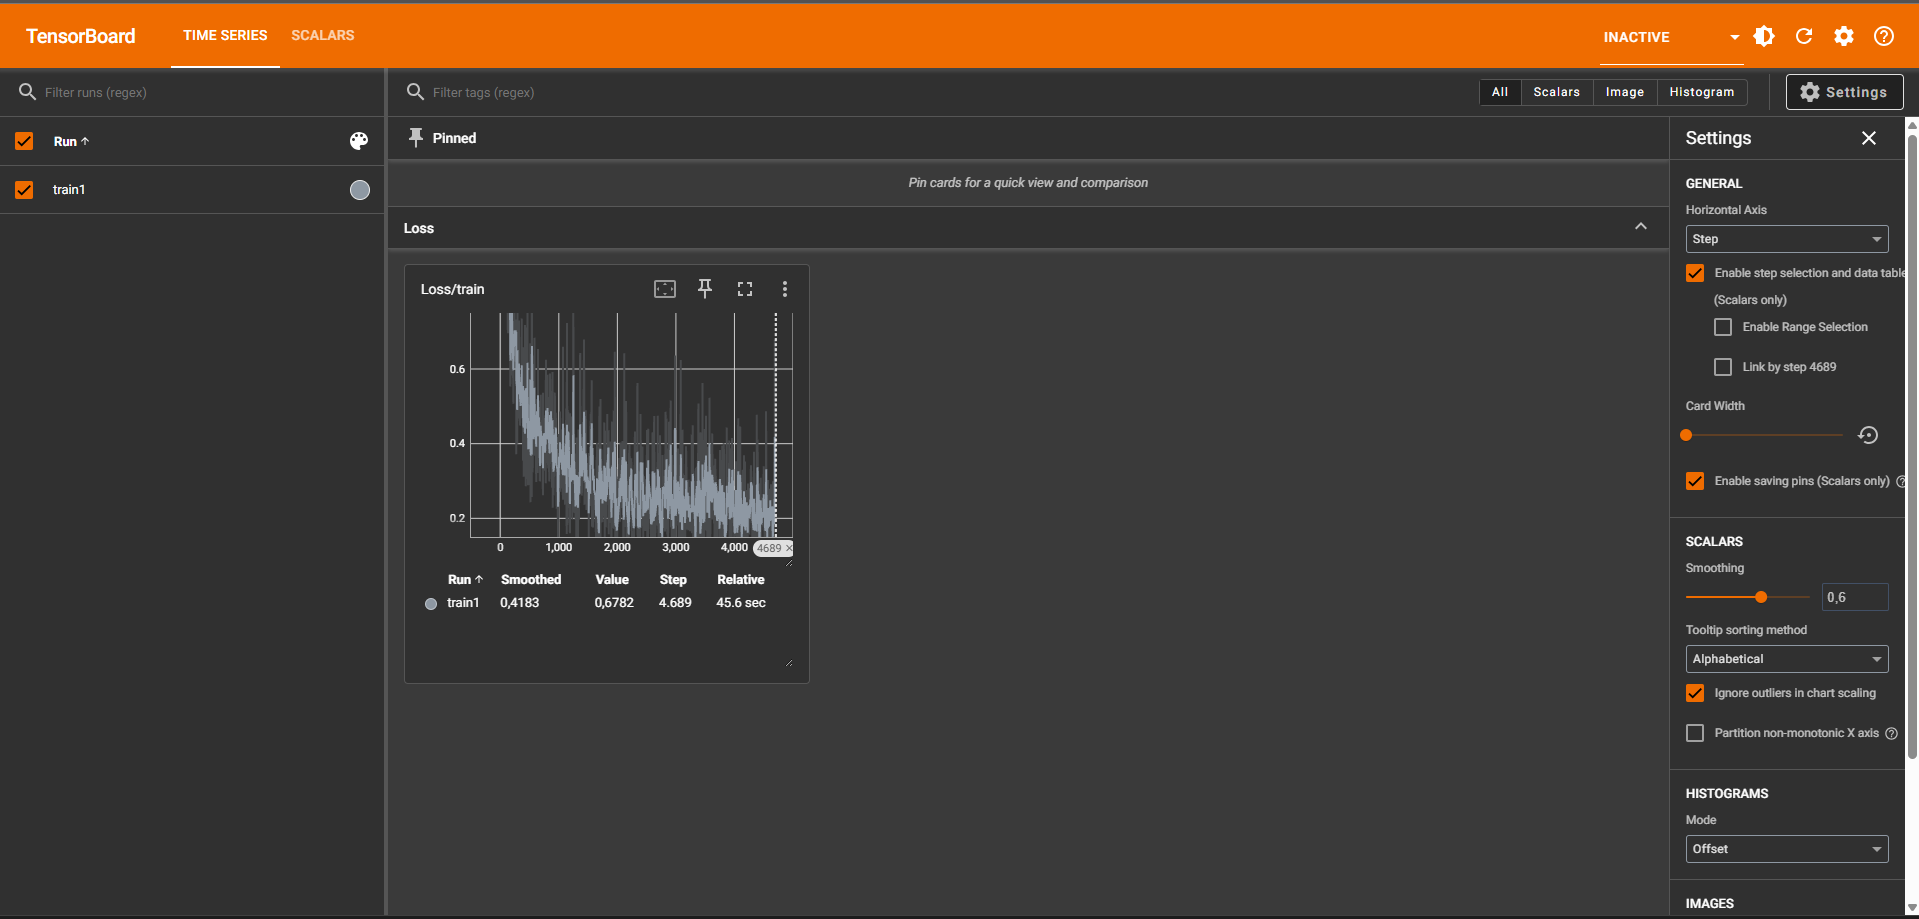

In [52]:
# Chạy tensor board
# !tensorboard --logdir=runs
listener.close()

<Future pending cb=[<builtins.PyDoneCallback object at 0x7af2f15f3130>()]>

<a id="sec10"></a>
# __10. Lưu và load model checkpoint__

<a id="sec10_1"></a>
## 10.1. State dict
PyTorch gói toàn bộ trọng số vào `state_dict` (nó có kiểu dữ liệu `dict`)

In [56]:
for ten, mat in model.state_dict().items():
  # tensor là ma trận trọng số hoặc vector bias
  print(f"{ten} -> {tuple(mat.shape)}")

net.1.weight -> (128, 784)
net.1.bias -> (128,)
net.4.weight -> (64, 128)
net.4.bias -> (64,)
net.7.weight -> (10, 64)
net.7.bias -> (10,)


In [57]:
torch.save(model.state_dict(), 'model.pth')   # ghi trọng số ra file

```python
# ---- LƯU CHECKPOINT ĐẦY ĐỦ ----
checkpoint = {
    'epoch': epoch,                              # đang train tới vòng nào
    'model_state_dict': model.state_dict(),      # trọng số model
    'optimizer_state_dict': optimizer.state_dict(),  # trạng thái optimizer (Adam m, v...)
    'loss': loss.item(),                         # loss gần nhất, để tham khảo
}
torch.save(checkpoint, 'checkpoint.pth')

# ---- LOAD ĐỂ TRAIN TIẾP ----
model = MyModel()                    # dựng lại kiến trúc
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

checkpoint = torch.load('checkpoint.pth')
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
start_epoch = checkpoint['epoch'] + 1     # train tiếp từ vòng kế
last_loss = checkpoint['loss']

model.train()    # train tiếp -> bật chế độ train
for epoch in range(start_epoch, 100):
    ...          # vòng train bình thường
```

```python
model.load_state_dict(torch.load('model.pth'))
model.eval()                      # BẮT BUỘC trước khi dự đoán

with torch.no_grad():             # thêm nữa: tắt tính gradient cho nhẹ & nhanh
    du_doan = model(du_lieu_moi)
```

<a id="sec11"></a>
# __11. Tinh chỉnh learning rate schedule__

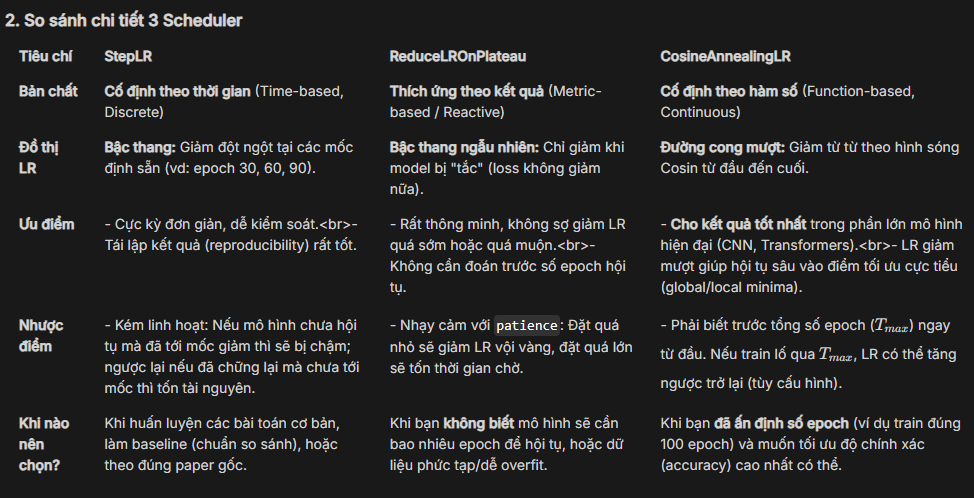

In [62]:
model3 = MLP2().to(device)
optimizer = torch.optim.Adam(model3.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(EPOCHS):
  model3.train()
  for image, label in train_loader:
    img = image.to(device)
    lb = label.to(device)

    optimizer.zero_grad()
    y_pred = model3(img)
    loss = loss_fn(y_pred, lb)

    loss.backward()
    optimizer.step()
  # --- hết một EPOCH mới bước scheduler MỘT lần ---
  scheduler.step() # Cập nhật scheduler
  lr_now = scheduler.get_last_lr()[0]
  print(f"Epoch {epoch}: lr = {lr_now:.4f}")

Epoch 0: lr = 0.0009
Epoch 1: lr = 0.0007
Epoch 2: lr = 0.0003
Epoch 3: lr = 0.0001
Epoch 4: lr = 0.0000
